In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [2]:
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AIML Dataset.csv")

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.shape


(6362620, 11)

In [7]:
df["isFraud"].value_counts()

,count
isFraud,
0,6354407
1,8213


In [8]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [9]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100, 2)

np.float64(0.13)

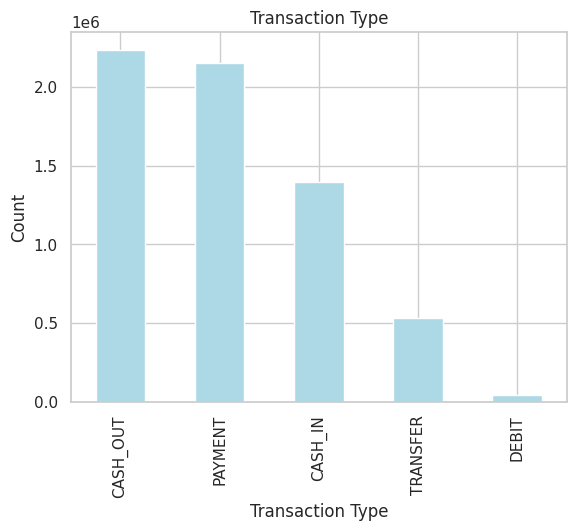

In [10]:
df["type"].value_counts().plot(kind="bar", color="lightblue")
plt.title("Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

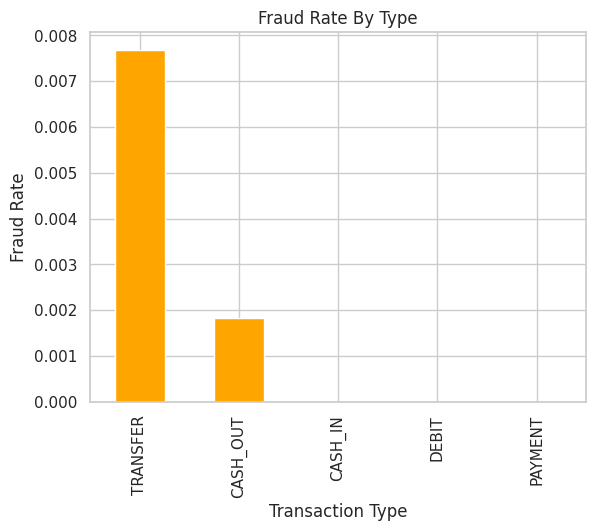

In [11]:
fraud_rate_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_rate_by_type.plot(kind="bar", title="Fraud Rate By Type", color="orange")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

In [12]:
df["amount"].describe().astype(int)

,amount
count,6362620
mean,179861
std,603858
min,0
25%,13389
50%,74871
75%,208721
max,92445516


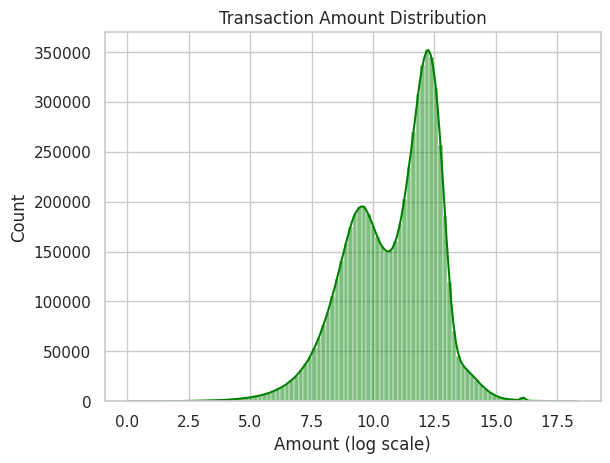

In [13]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.xlabel("Amount (log scale)")
plt.title("Transaction Amount Distribution")
plt.show()

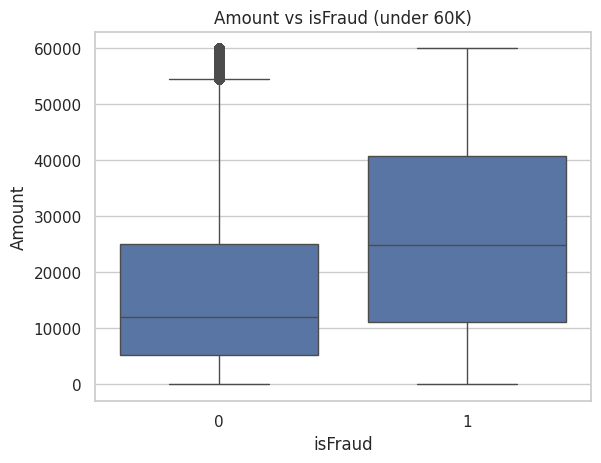

In [14]:
sns.boxplot(data=df[df["amount"] < 60000], x="isFraud", y="amount")
plt.title("Amount vs isFraud (under 60K)")
plt.xlabel("isFraud")
plt.ylabel("Amount")
plt.show()

In [15]:
balanceDiffOrg = df['oldbalanceOrg'] - df['newbalanceOrig']
balanceDiffDest = df['newbalanceDest'] - df['oldbalanceDest']

In [16]:
(balanceDiffOrg < 0).sum()
(balanceDiffDest < 0).sum()

np.int64(1238864)

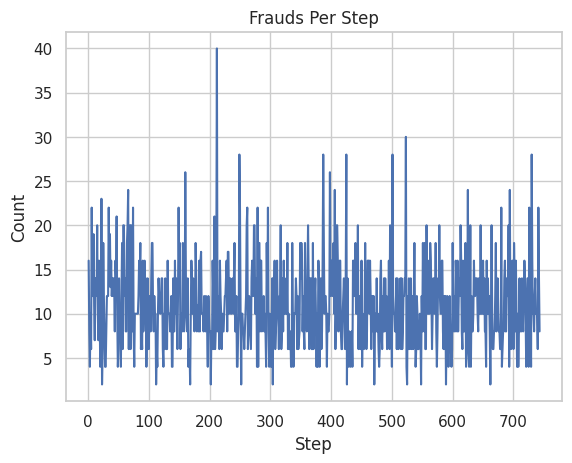

In [17]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds Per Step")
plt.title("Frauds Per Step")
plt.xlabel("Step")
plt.ylabel("Count")
plt.show()


In [18]:
df.drop(columns="step", inplace=True)

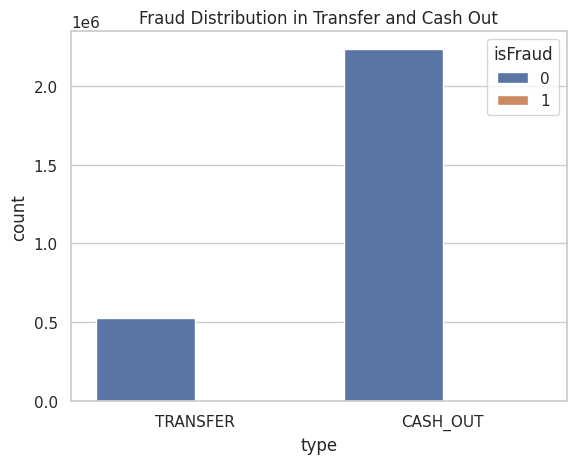

In [19]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer and Cash Out")
plt.show()

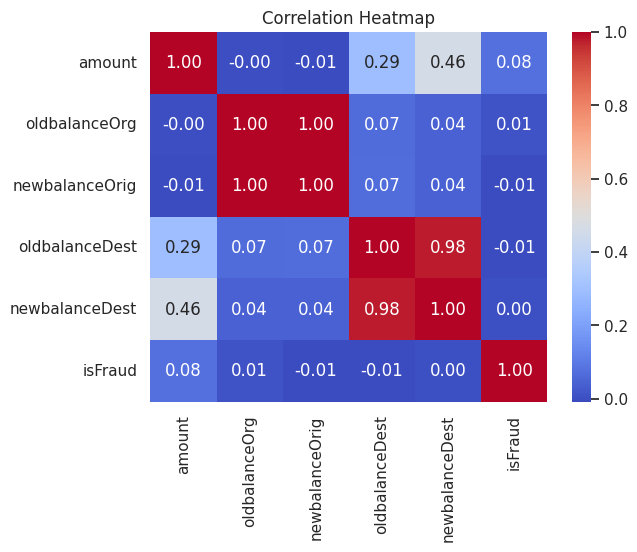

In [20]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()
sns.heatmap(data=corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

In [22]:
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)

In [23]:
categorical = ["type"]
numerical = ["oldbalanceOrg", "amount", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [24]:
X = df_model.drop("isFraud", axis=1)
y = df_model["isFraud"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.3, stratify=y
)

In [26]:
class SimplePreprocessor(BaseEstimator, TransformerMixin):

    def __init__(self, numerical, categorical):
        self.numerical = numerical
        self.categorical = categorical
        self.scaler = StandardScaler()
        self.encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    def fit(self, X, y=None):
        self.scaler.fit(X[self.numerical])
        self.encoder.fit(X[self.categorical])
        return self

    def transform(self, X):
        X_num = self.scaler.transform(X[self.numerical])
        X_cat = self.encoder.transform(X[self.categorical])
        return np.hstack([X_num, X_cat])

In [43]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # replaces sklearn Pipeline
from xgboost import XGBClassifier

pipeline = ImbPipeline([
    ("prep", SimplePreprocessor(numerical, categorical)),
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="aucpr",
        use_label_encoder=False,
        n_jobs=-1
    ))
])

In [44]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 SimplePreprocessor(categorical=['type'],
                                    numerical=['oldbalanceOrg', 'amount',
                                               'newbalanceOrig',
                                               'oldbalanceDest',
                                               'newbalanceDest'])),
                ('smote', SMOTE(random_state=42)),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_roun...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [45]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [46]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold: {best_threshold:.4f} | Best F1: {f1_scores.max():.4f}")

Best Threshold: 0.9950 | Best F1: 0.8584


In [47]:
y_pred = (y_prob > best_threshold).astype(int)

In [48]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"Accuracy: {pipeline.score(X_test, y_test) * 100:.2f}%")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.92      0.81      0.86      2464

    accuracy                           1.00   1908786
   macro avg       0.96      0.90      0.93   1908786
weighted avg       1.00      1.00      1.00   1908786

[[1906144     178]
 [    478    1986]]
Accuracy: 99.78%


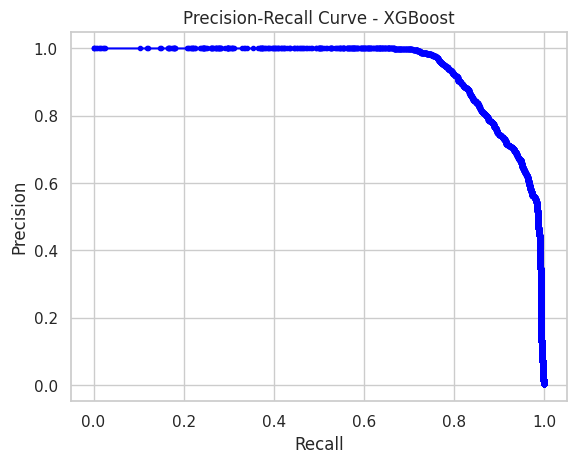

In [49]:
plt.plot(recall, precision, marker='.', color='blue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.show()

In [50]:
joblib.dump(pipeline, "Fraud_Detection_XGB_model.pkl")

['Fraud_Detection_XGB_model.pkl']